# 6. Quantitative structure models

From the points of one tree to a connected set of cylinders with volumes and
branch orders. This one starts on a synthetic tree, whose stem volume follows
from its taper, so the model can be checked against a known answer; a real
tree from the Litchfield tile follows.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.style.use("sylva.mplstyle")     # shared figure style; C0 to C7 are the Okabe-Ito colours
GROUND, WOOD, LEAF, GRASS, CONTEXT = "#997A5C", "#4D2B12", "#009E73", "#E69F00", "0.8"   # the same in every notebook
DIVERGING = "RdBu_r"                # for signed differences, centred on zero
LABELS = ListedColormap(["#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77",
                         "#CC6677", "#882255", "#AA4499"])   # tree ids and clusters: Paul Tol's muted set
from sylva import qsm

tree = synthetic.tree(dbh=0.35, height=14.0, seed=4)
print(tree)

PointCloud(n=79,004, attrs=['classification'])


## Leaf / wood separation

`wood_points` combines local anisotropy with a topological cue: points that many
shortest paths from the base to the crown pass through are wood. The synthetic
tree knows which points are wood, so the filter can be checked.

28,264 wood points kept; 98.4% of them lie on true wood


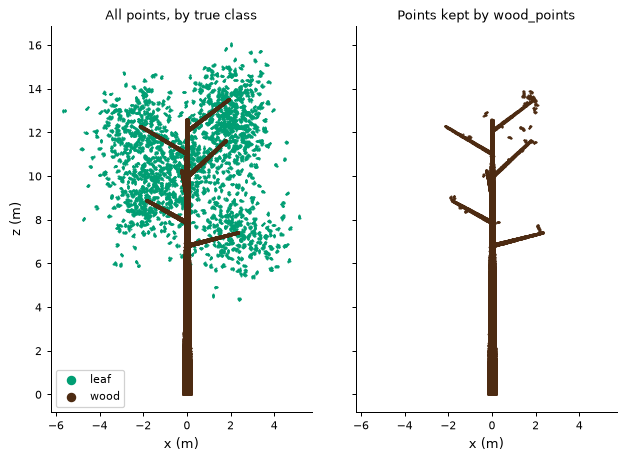

In [2]:
wood = qsm.wood_points(tree, voxel_size=0.02)
true_wood = tree[tree.attrs["classification"] == 5]
from sylva import filters
d, _ = filters.knn(true_wood.xyz, wood.xyz, 1)
print(f"{len(wood):,} wood points kept; {np.mean(d[:, 0] < 0.03):.1%} of them lie on true wood")

is_wood = tree.attrs["classification"] == 5
fig, ax = plt.subplots(1, 2, figsize=(7, 5), sharex=True, sharey=True)
ax[0].scatter(tree.x[~is_wood], tree.z[~is_wood], s=0.3, c=LEAF, label="leaf")
ax[0].scatter(tree.x[is_wood], tree.z[is_wood], s=0.3, c=WOOD, label="wood")
ax[0].set(title="All points, by true class", aspect="equal", xlabel="x (m)", ylabel="z (m)")
ax[0].legend(markerscale=12, loc="lower left")
ax[1].scatter(wood.x, wood.z, s=0.3, c=WOOD)
ax[1].set(title="Points kept by wood_points", aspect="equal", xlabel="x (m)");

## Cylinder model

In [3]:
model = qsm.build_qsm(wood, base_xy=(0.0, 0.0))
for k, v in model.summary().items():
    print(f"{k:18s} {v:.4f}" if isinstance(v, float) else f"{k:18s} {v}")

n_cylinders        343
total_volume_m3    0.6210
stem_volume_m3     0.5788
branch_volume_m3   0.0422
total_length_m     38.2044
max_branch_order   2
dbh_m              0.3373


The stem of the synthetic tree tapers from 1.05 to 0.25 times the breast-height radius over 90 % of the height, so its volume is known:

In [4]:
r0, r1, L = 0.35 / 2 * 1.05, 0.35 / 2 * 0.25, 14.0 * 0.9
true_stem = np.pi * L / 3 * (r0**2 + r0 * r1 + r1**2)
print(f"stem volume: model {model.stem_volume:.3f} m3, truth {true_stem:.3f} m3;  DBH: model {model.dbh:.3f} m, truth 0.35 m")

stem volume: model 0.579 m3, truth 0.577 m3;  DBH: model 0.337 m, truth 0.35 m


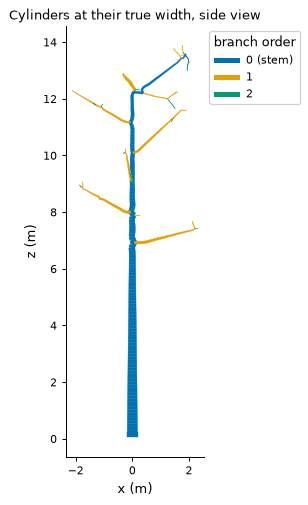

In [5]:
from matplotlib.collections import PolyCollection

# Each cylinder drawn at its true width: the outline of its side view.
a, b = model.start[:, [0, 2]], model.end[:, [0, 2]]
d = b - a
n = np.c_[-d[:, 1], d[:, 0]] / np.maximum(np.hypot(*d.T), 1e-9)[:, None] * model.column("radius")[:, None]
order = model.column("branch_order").astype(int)
fig, ax = plt.subplots(figsize=(5, 5.5))
colours = [f"C{min(o, 7)}" for o in order]
ax.add_collection(PolyCollection(np.stack([a + n, b + n, b - n, a - n], axis=1),
                                 facecolor=colours, edgecolor=colours, lw=0.3))
ax.autoscale_view()
for o in np.unique(order):
    ax.plot([], [], c=f"C{min(o, 7)}", lw=4, label="0 (stem)" if o == 0 else str(o))
ax.legend(title="branch order", loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.set(aspect="equal", xlabel="x (m)", ylabel="z (m)", title="Cylinders at their true width, side view");

## A real tree, and why to check `measured_volume_fraction`

The same steps on the tallest tree of the Litchfield tile (notebook 5). The
tile is thinned to 5 cm and cut out of a decimated ray cloud, so the trunk and
branches are sampled far more thinly than a single-tree scan: most cylinders
end up interpolated rather than fitted. `metrics()["measured_volume_fraction"]`
says how much of the volume came from real fits, and it is the flag to filter
on before using QSM volumes.

In [6]:
from sylva import filters, ground, trees

plot = filters.voxel_downsample(sylva.read(DATA / "litch_tile.laz"), 0.02)
plot = ground.normalize_height(plot, ground.make_dtm(ground.classify_ground_pmf(plot), 0.5, bounds=(0, 0, 20, 20)))
stems = trees.detect_stems(plot)
stems, _ = trees.merge_branches(plot, stems)
labels = trees.segment_trees(plot, stems)
trees.tree_heights(plot, labels, stems)
stems, labels = trees.prune_trees(stems, labels, min_height=3.0)
tallest = max(stems, key=lambda t: t.height)

points = plot[labels == tallest.tree_id]
points = points[points.attrs["height"] > 0.3]      # leave the grass layer out of the base fit
real = qsm.build_qsm(qsm.wood_points(points, voxel_size=0.02), base_xy=(tallest.x, tallest.y))
print(f"detection: DBH {tallest.dbh:.3f} m, height {tallest.height:.1f} m")
print(f"QSM:       DBH {real.dbh:.3f} m, stem {real.stem_volume:.2f} m3, total {real.total_volume:.2f} m3, "
      f"{real.summary()['n_cylinders']} cylinders")
m = real.metrics()
print(f"fitted to points: {m['measured_volume_fraction']:.0%} of the volume, "
      f"{m['measured_length_fraction']:.0%} of the length")

detection: DBH 0.316 m, height 20.0 m
QSM:       DBH 0.319 m, stem 1.09 m3, total 1.67 m3, 5068 cylinders
fitted to points: 63% of the volume, 4% of the length


Two lessons. The DBHs agree (0.316 m against 0.319 m), because breast
height is where the stem is best sampled. The two fractions differ widely:
nearly two thirds of the volume lies in the trunk and the main limbs, which
were fitted to points, but only 4 % of the length was, so the finer branches
come from the taper and pipe-model priors. The stem volume is supported by
the data here; a third of the total volume, and the branch length, are not. The height cut keeps the
grass layer out of the base fit; on this tree it changes little, but tussocks
against a trunk can widen the base cylinder. Volumes are validated against felled
trees in [Benchmarks](../benchmarks/qsm.md), on single-tree clouds two orders
of magnitude denser than this tile.

## Export

A cylinder table, a raycloudtools-style tree file, and meshes for Blender / CloudCompare.

In [7]:
model.to_csv("tree_qsm.csv")
model.to_ply("tree_qsm.ply")        # faces coloured by branch order
model.to_obj("tree_qsm.obj")
qsm.QSM.from_csv("tree_qsm.csv").summary()["n_cylinders"]

343